**Lab 3**

Train a custom Word2Vec model on a small dataset. Train embeddings on a domain-specific corpus (e.g., Legal, Medical) and analyze how embeddings capture domain-specific semantics.

In [1]:
# Import required modules
import matplotlib.pyplot as plt
import numpy as np

from sklearn.manifold import TSNE
from gensim.models import Word2Vec

In [2]:
# Sample domain-specific corpus (Medical)
medical_corpus = [
    "The patient was diagnosed with diabetes and hypertension.",
    "MRI scans reveal abnormalities in the brain tissue.",
    "The treatment involves antibiotics and regular monitoring.",
    "Symptoms include fever, fatigue, and muscle pain.",
    "The vaccine is effective against several viral infections.",
    "Doctors recommend physical therapy for recovery.",
    "The clinical trial results were published in the journal.",
    "The surgeon performed a minimally invasive procedure.",
    "The prescription includes pain relievers and anti-inflammatory drugs.",
    "The diagnosis confirmed a rare genetic disorder.",
]

In [ ]:
# Preprocess corpus (tokenize sentences and convert to lowercase)
processed_corpus = [sentence.lower().split() for sentence in medical_corpus]

In [4]:
# Train a Word2Vec model
model = Word2Vec(
    sentences=processed_corpus,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    epochs=50,
)

In [ ]:
# Extract embeddings for visualization
words = list(model.wv.index_to_key)
embeddings = np.array([model.wv[word] for word in words])

In [6]:
# Dimensionality reduction using t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
tsne_result = tsne.fit_transform(embeddings)

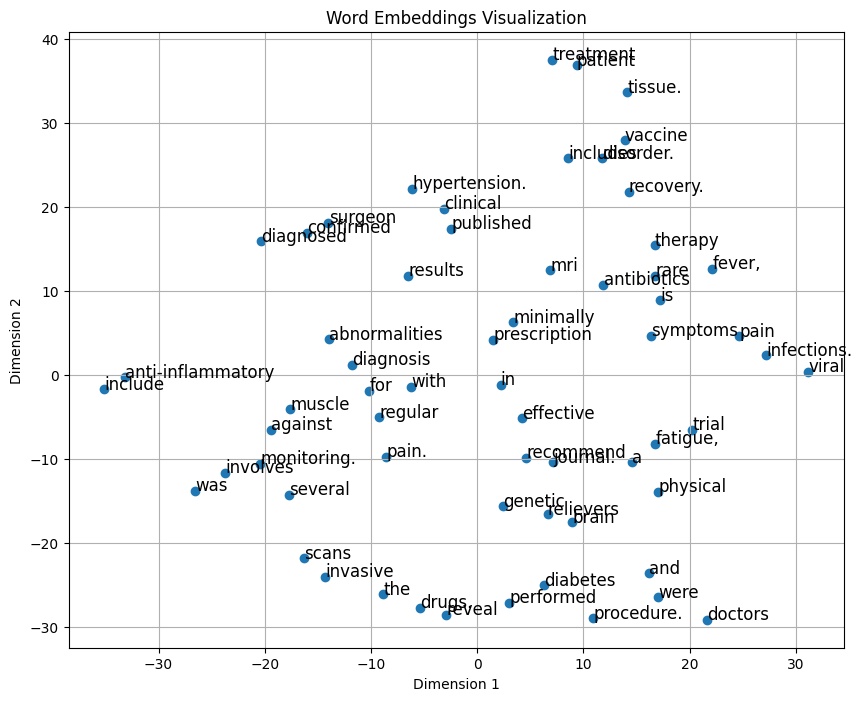

In [34]:
# Visualization of word embeddings
plt.figure(figsize=(10, 8))
plt.scatter(tsne_result[:, 0], tsne_result[:, 1])
for i, word in enumerate(words):
    plt.text(tsne_result[i, 0] + 0.02, tsne_result[i, 1] + 0.02, str(word), fontsize=12)
plt.title("Word Embeddings Visualization")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True)
plt.show()

In [33]:
# Analyze domain-specific semantics
def find_similar_words(input_word, top_n=5):
    try:
        similar_words = model.wv.most_similar(input_word, topn=top_n)
        print(f"Words similar to '{input_word}':\n")
        for word, similarity in similar_words:
            print(f"{word}\t({similarity:.2f})")
    except KeyError:
        print(f"'{input_word}' not found in vocabulary.")

In [35]:
# Generate semantically similar words
find_similar_words("treatment")

Words similar to 'treatment':

patient	(0.25)
pain.	(0.14)
brain	(0.12)
against	(0.11)
muscle	(0.11)


In [36]:
# Generate semantically similar words
find_similar_words("vaccine")

Words similar to 'vaccine':

disorder.	(0.20)
tissue.	(0.14)
recovery.	(0.12)
therapy	(0.10)
doctors	(0.09)
